# Trend Scout — щоденний AI-дайджест у Telegram (LangGraph)

**Фінальний проєкт** · курс Generative AI Developer (robot_dreams) · Роман Мицко · липень 2026

Репозиторій: https://github.com/RomanMytsko/trend-scout

**Ідея.** Trend Scout запускається щодня, досліджує rolling date window, відбирає нові історії та готує Telegram-пост. Архітектура — чотири LLM-агенти й детерміновані workers у явному LangGraph:

```text
planner → researcher → curator → writer → judge → publisher → archive → END
   ↑           │          │         ↑         │
   └── replan ─┴──────────┘         └ revise ─┘
                                      │
                         hard fail / budget → reject → END
```

| Вузол | Тип | Відповідальність |
|---|---|---|
| planner | LLM-агент | 2–6 запитів для точної дати та заданих тем |
| researcher | worker | RSS + паралельний DDG, URL/semantic dedupe, delivered-memory |
| curator | LLM-агент | ранжування під аудиторію, унікальні picks |
| writer | LLM-агент | Markdown-дайджест і ревізії за фідбеком |
| judge | guardrail + LLM | hard URL/format checks і рубрика 1–5 |
| publisher | worker | Telegram або локальний preview |
| archive | memory | запамʼятовує лише підтверджено доставлені історії |
| reject | terminal | fail-closed: нічого не надсилає й не архівує |

Replan і revise мають жорсткі бюджети. Після їх вичерпання невдалий дайджест блокується, а не публікується best-effort.

In [1]:
import pathlib
import subprocess
import sys

# Local execution uses this checkout; Colab installs the public repository.
if pathlib.Path("pyproject.toml").exists():
    package = "."
elif pathlib.Path("../pyproject.toml").exists():
    package = ".."
else:
    package = "git+https://github.com/RomanMytsko/trend-scout.git"
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
print("trend-scout installed from", package)

trend-scout installed from ..


## API-ключ

Потрібен лише `OPENAI_API_KEY` (пошук і RSS — безключові). У Colab додай ключ у **Secrets** (іконка 🔑 зліва) або введи нижче.

In [2]:
import os

if not os.environ.get("OPENAI_API_KEY"):
    try:
        from google.colab import userdata
        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    except Exception:
        import getpass
        os.environ["OPENAI_API_KEY"] = getpass.getpass("OPENAI_API_KEY: ")

os.environ.setdefault("DIGEST_LANGUAGE", "Ukrainian")
os.environ.setdefault("AUDIENCE", "backend Python engineer")
os.environ.setdefault("DAYS_BACK", "7")  # daily schedule, rolling week
print("Configuration ready; API key is not displayed.")

Configuration ready; API key is not displayed.


## Візуалізація графа

LangGraph компілює `StateGraph` з умовними переходами — подивимось на нього.

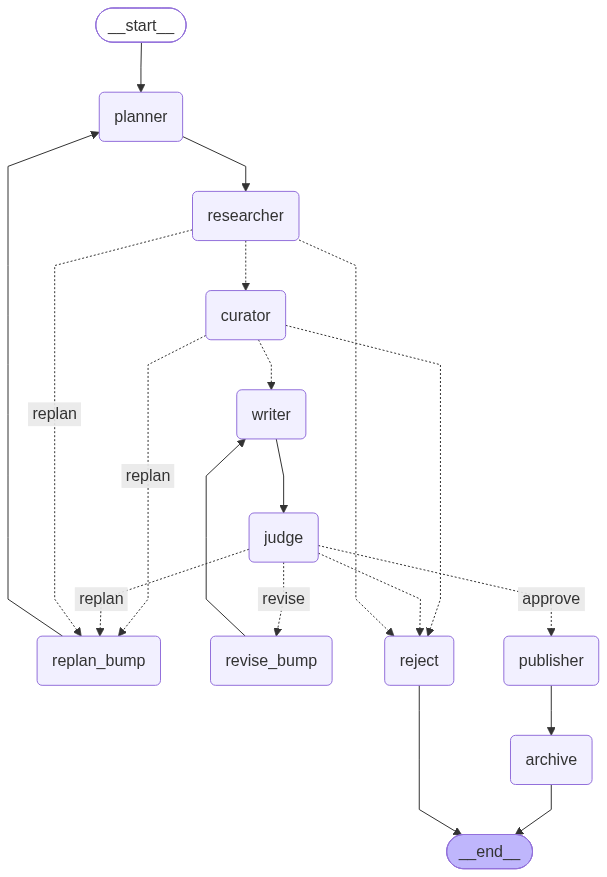

In [3]:
from trend_scout import graph

app = graph.build_graph()

try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())  # fallback: mermaid-текст

## Запуск пайплайну

Теми можна міняти. Baseline — 4 chat-model calls; bounded replan/revise loops можуть збільшити максимум до 12. DDG є keyless і часом throttled, тому тематичні RSS залишаються fallback.

In [4]:
TOPICS = [
    "multi-agent orchestration",
    "MCP and A2A protocols",
    "LangGraph and agent frameworks",
    "context engineering",
]

state = graph.run_digest(TOPICS)

print("--- pipeline events ---")
for event in state["events"]:
    print(" ", event)
print("delivery_status:", state.get("delivery_status", "not reached"))

Web search failed for query 'multi-agent orchestration frameworks 2026 Python backend': No results found.


Web search failed for query 'Python libraries for multi-agent orchestration July 2026 release notes or updates 2026-07-12..2026-07-19 site:github.com or site:medium.com or site:arxiv.org or site:researchgate.net or site:stackoverflow.com': No results found.


--- pipeline events ---
  planner: 6 queries
  researcher: 26 rss + 12 search -> 36 unique items
  curator: picked 5 items
  writer: draft #0 ready
  judge: relevance=5 grounding=5 format=4 avg=4.67
  publisher: dry-run (channel not configured), post saved to telegram_post_preview.html
  archive: skipped (delivery status preview)
delivery_status: preview


## Оцінка якості: hard guardrail + LLM-as-a-judge

Спочатку код перевіряє структуру та URL allowlist. Далі LLM-суддя оцінює relevance, grounding і format. Невдалий hard check або будь-який criterion score нижче 4.0 запускає bounded recovery; після вичерпання бюджету route=`reject`, тож Telegram і delivered-memory недоступні.

In [5]:
verdict = state.get("verdict")
if verdict:
    print(f"relevance    : {verdict.relevance}/5")
    print(f"grounding    : {verdict.grounding}/5")
    print(f"format       : {verdict.format_score}/5")
    print(f"average      : {verdict.average:.2f}")
    print(f"criteria pass: {verdict.passes(4.0)} (кожен score >= 4.0)")
    print(f"ревізій      : {state.get('revisions', 0)}")
    print(f"replan-ів    : {state.get('replans', 0)}")
    print(f"hard failure : {state.get('hard_guardrail_failed', False)}")
    print(f"delivery     : {state.get('delivery_status', 'not reached')}")
    print(f"\nфідбек судді: {verdict.feedback}")
else:
    print("No judge verdict: research/curation was blocked earlier.")

relevance    : 5/5
grounding    : 5/5
format       : 4/5
average      : 4.67
criteria pass: True (кожен score >= 4.0)
ревізій      : 0
replan-ів    : 0
hard failure : False
delivery     : preview

фідбек судді: The digest is highly relevant to the topics of multi-agent orchestration, MCP and A2A protocols, LangGraph and agent frameworks, and context engineering, and it suits the backend Python engineer audience well. All claims are well grounded in the source items with accurate titles, snippets, and URLs. The content is well structured and informative. However, the format slightly deviates from the exact required Ukrainian structure: the title should be exactly one '# ' heading, followed by one intro sentence, then each item should have a '## <N>. <title>' heading and exactly one '- Суть:', '- Чому важливо:' and '- Лінк:' bullet line. The draft uses the correct bullet lines but the intro sentence is not separated clearly from the title by a blank line, and the bullet lines use a colon

## Результат — дайджест

In [6]:
from IPython.display import Markdown, display

display(Markdown(state["digest"]))

# Огляд новин про AI-агентів для backend Python-інженерів

Цей дайджест охоплює останні дослідження та події у сфері протоколів, безпеки, прозорості та координації AI-агентів, що важливо для розробників backend на Python.

## 1. Competing AI Agent Protocols Face IETF Standards Scrutiny at Vienna Meeting  
- Суть: На конференції IETF 126 у Відні розпочато розгляд стандартів для протоколів AI-агентів. Обговорюються конкуренційні протоколи для взаємодії агентів.  
- Чому важливо: Стандартизація вплине на сумісність і інтеграцію багатьох AI-агентів у backend-системах.  
- Лінк: [Tech Times](https://www.techtimes.com/articles/320919/20260718/competing-ai-agent-protocols-face-ietf-standards-scrutiny-vienna-meeting.htm)

## 2. Codex Multi-Agent V2 update raises developer concerns over agent transparency  
- Суть: Оновлення Codex Multi-Agent V2 зменшує видимість взаємодій агентів, що ускладнює налагодження, управління та відповідність регуляціям. Це може затримати впровадження у критичних системах.  
- Чому важливо: Прозорість агентів є ключовою для ефективного дебагу та підтримки backend-сервісів з AI-агентами.  
- Лінк: [InfoWorld](https://www.infoworld.com/article/4197328/codex-multi-agent-v2-update-raises-developer-concerns-over-agent-transparency.html)

## 3. Bad Memory: Evaluating Prompt Injection Risks from Memory in Agentic Systems  
- Суть: Агентні системи з постійною пам’яттю вразливі до атак через ін’єкції команд у збережені файли, що може змінити поведінку агентів. Досліджено ці ризики на прикладі систем Anthropic Claude Code та OpenAI Codex.  
- Чому важливо: Безпека збережених станів агентів критична для надійності backend-рішень з AI.  
- Лінк: [arXiv](https://arxiv.org/abs/2607.14611v1)

## 4. Consensys Deploys AI Agent Dispute Resolution Protocol for MetaMask  
- Суть: Consensys впроваджує протокол вирішення спорів між AI-агентами на базі MetaMask, що слугуватиме гаманцем і платіжною інфраструктурою для Internet Court.  
- Чому важливо: Приклад реального застосування AI-агентів у децентралізованих фінансах демонструє можливості інтеграції агентних протоколів у backend.  
- Лінк: [Tokenist](https://tokenist.com/internet-court-erc-7710-ai-agent-dispute-resolution-metamask/)

## 5. Stigmergic Graph Memory: An Environment-Aware Approach for Many-to-Many Multi-Agent Pickup and Delivery  
- Суть: Запропоновано метод Stigmergic Graph Memory для координації багатьох агентів у системах доставки, що враховує навантаження і трафік у реальному часі. Це покращує планування маршрутів і розподіл завдань.  
- Чому важливо: Новий підхід допоможе масштабувати багатокористувацькі AI-системи з оптимізованою маршрутизацією на backend.  
- Лінк: [arXiv](https://arxiv.org/abs/2607.15182v1)

## Зазирнемо всередину: проміжні стани агентів

In [7]:
print("PLAN (planner, structured output):")
print("  reasoning:", state["plan"].reasoning)
for q in state["plan"].queries:
    print("  query:", q)

print(f"\nITEMS (researcher): {len(state.get('items', []))} після dedupe/memory, приклади:")
for item in state.get("items", [])[:5]:
    print(f"  [{item.source}] {item.title[:80]}")

print("\nCURATION (curator):")
for pick in (state["curation"].picks if state.get("curation") else []):
    print(f"  #{pick.index} relevance={pick.relevance}: {pick.why_it_matters[:100]}")

PLAN (planner, structured output):
  reasoning: To provide a backend Python engineer with up-to-date and relevant information on multi-agent orchestration, MCP and A2A protocols, LangGraph and agent frameworks, and context engineering, the queries focus on recent developments, practical implementations, and technical details within the specified date window. The queries are designed to capture both theoretical and applied aspects, ensuring coverage of protocols, frameworks, and engineering practices relevant to Python backend development.
  query: multi-agent orchestration frameworks 2026 Python backend
  query: MCP protocol updates July 2026
  query: A2A communication protocols in multi-agent systems 2026
  query: LangGraph agent framework new features July 2026
  query: context engineering techniques for AI agents 2026
  query: Python libraries for multi-agent orchestration July 2026 release notes or updates 2026-07-12..2026-07-19 site:github.com or site:medium.com or site:arxiv.org 

## Telegram delivery status

Без credentials publisher працює у preview mode: HTML зберігається локально, але не вважається доставленим і не потрапляє в delivered-memory. З `TELEGRAM_BOT_TOKEN` та `TELEGRAM_CHANNEL_ID` успішна Bot API відповідь дає `delivery_status=sent`, після чого archive може записати історії в Chroma. Для multi-message постів локальний delivery journal запамʼятовує підтверджені chunks і після обробленої помилки продовжує з першого ненадісланого.

In [8]:
post = state.get("post", "")
print(post[:800] if post else "No post was rendered because the run stopped before publishing.")

<b>Огляд новин про AI-агентів для backend Python-інженерів</b>

Цей дайджест охоплює останні дослідження та події у сфері протоколів, безпеки, прозорості та координації AI-агентів, що важливо для розробників backend на Python.

<b>1. Competing AI Agent Protocols Face IETF Standards Scrutiny at Vienna Meeting</b>
• Суть: На конференції IETF 126 у Відні розпочато розгляд стандартів для протоколів AI-агентів. Обговорюються конкуренційні протоколи для взаємодії агентів.  
• Чому важливо: Стандартизація вплине на сумісність і інтеграцію багатьох AI-агентів у backend-системах.  
• Лінк: <a href="https://www.techtimes.com/articles/320919/20260718/competing-ai-agent-protocols-face-ietf-standards-scrutiny-vienna-meeting.htm">Tech Times</a>

<b>2. Codex Multi-Agent V2 update raises developer concern


## Семантична дедуплікація та delivered-memory

Embeddings використовуються двічі: для схлопування cross-outlet дублікатів і для пошуку історій, уже **реально доставлених** раніше. Preview не змінює production-memory, тому нижче memory-контракт демонструється окремо на ephemeral Chroma client.

In [9]:
import chromadb

from trend_scout import memory

embeddings = state.get("item_embeddings") or []
picks = state.get("curation").picks if state.get("curation") else []
if embeddings and picks:
    client = chromadb.EphemeralClient()
    picked_items = [state["items"][p.index] for p in picks]
    picked_embeddings = [embeddings[p.index] for p in picks]
    print("before remember:", memory.filter_unseen_indices(picked_embeddings, client=client))
    memory.remember(picked_items, picked_embeddings, client=client)
    print("after remember :", memory.filter_unseen_indices(picked_embeddings, client=client))
else:
    print("Embedding step degraded gracefully; memory demo skipped for this run.")

before remember: [0, 1, 2, 3, 4]
after remember : []


## Висновки

- Явний LangGraph координує чотири LLM-ролі та детерміновані workers.
- Pydantic structured outputs застосовані до decision agents; Markdown writer перевіряється окремо.
- Hard URL/format guardrails працюють fail-closed; LLM judge дає bounded feedback loop.
- Semantic dedupe і Chroma delivered-memory вирішують різні задачі повторів.
- Delivery status відділяє `sent`, `preview`, `failed` і `blocked`; archive доступний лише після `sent`.
- Обмеження чесні: snippets замість full text, DDG throttling, емпіричні cosine thresholds і same-model judge за замовчуванням.

Наступний production-крок — приватний Telegram-канал і зовнішній scheduler; credentials у репозиторій не додаються.